# Grammar Scoring Engine for Spoken Audio (SHL Hiring Assessment 2026)

**Task:** predict a continuous MOS-style grammar score (0 to 5) from a 45-60 s speech clip.
**Data:** 769 labelled training clips, 216 test clips. **Metric:** RMSE (lower is better).

## Report

**Approach.** Grammar quality shows up in *how* someone speaks (sentence completeness, hesitations, repairs, fluency) as well as in the words. I use a pretrained speech encoder (OpenAI Whisper) as a frozen feature extractor, mean-pool its hidden states over time, and fit a regularised linear model on top. With only 769 labelled clips, a frozen encoder plus ridge regression is far less likely to overfit than fine-tuning, and it is easy to explain and reproduce.

**Preprocessing.** Audio is loaded as 16 kHz mono. Clips are split into 30 s windows (Whisper's native input length). Each window is turned into a log-Mel spectrogram, passed through the Whisper encoder, and every hidden layer is mean-pooled over the valid (non-padded) frames. Window vectors are averaged per clip. Features are standardised inside each CV fold.

**Pipeline.**
1. Extract per-layer embeddings with `whisper-small` (13 layers x 768) and `whisper-medium` (25 layers x 1024).
2. Score every layer on its own with 5-fold CV ridge regression (layer-wise plot below).
3. Concatenate the best layers per model, choose the number of layers by CV.
4. Blend the medium-encoder model with the small-encoder model (layers 6 + 12), with the blend weight chosen by CV.
5. Clip predictions to [0, 5].

**Earlier experiments (for context).** A model on handcrafted features from Whisper transcripts and word timestamps (words per minute, pause counts, repetition and filler rates, word confidence, sentence-length statistics) reached CV RMSE 0.7716 and public leaderboard 0.4822. Sentence-embedding features of the transcript alone were weak (CV RMSE 1.03). Whisper-small encoder embeddings (layers 6 + 12) reached CV RMSE 0.5598 and public leaderboard 0.4345; the final blend reached public leaderboard 0.4310.

**Data note.** `sample_submission.csv` does not match the audio (204 rows, most filenames absent from `test.csv` and the `test/` folder). Submissions are keyed on `test.csv` (216 files, all present in `test/`), which Kaggle accepted. `train/` and `test/` also reuse some filenames for different audio, so the code always keys on the split folder.

**Evaluation.** 5-fold cross-validation RMSE (out-of-fold) and the **training RMSE** are printed at the end of the notebook.

In [1]:
import os, json, time, warnings
import numpy as np, pandas as pd, torch, librosa
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import KFold
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from transformers import WhisperFeatureExtractor, WhisperModel
warnings.filterwarnings("ignore")

D = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"
WORK = "/kaggle/working"
DEV = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
print("device:", DEV)

device: cuda


## 1. Data and label distribution

train: (769, 2) | test: (216, 2)
all test.csv files exist in test/: True
baseline RMSE (always predict the mean): 1.2382


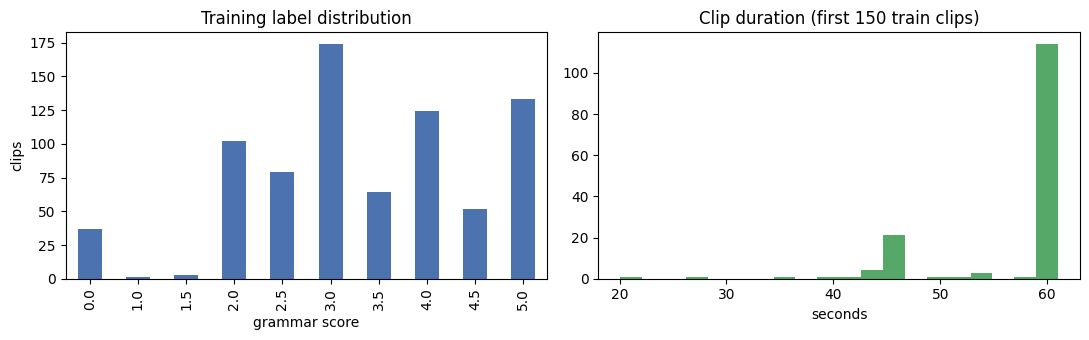

In [2]:
train = pd.read_csv(f"{D}/train.csv")
test = pd.read_csv(f"{D}/test.csv")
y = train.label.values.astype(float)
print("train:", train.shape, "| test:", test.shape)
print("all test.csv files exist in test/:", all(os.path.exists(f"{D}/test/{f}") for f in test.filename))
print("baseline RMSE (always predict the mean):", round(float(y.std()), 4))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
train.label.value_counts().sort_index().plot.bar(ax=ax[0], color="#4C72B0")
ax[0].set_title("Training label distribution"); ax[0].set_xlabel("grammar score"); ax[0].set_ylabel("clips")
dur = [librosa.get_duration(path=f"{D}/train/{f}") for f in train.filename[:150]]
ax[1].hist(dur, bins=20, color="#55A868"); ax[1].set_title("Clip duration (first 150 train clips)"); ax[1].set_xlabel("seconds")
plt.tight_layout(); plt.show()

## 2. Feature extraction: frozen Whisper encoders, every layer, mean-pooled over time

In [3]:
def extract_layers(model_name, split, filenames, cache):
    """Returns array (n_clips, n_layers+1, hidden) of time-averaged encoder hidden states."""
    if os.path.exists(cache):
        return np.load(cache)
    fe = WhisperFeatureExtractor.from_pretrained(model_name)
    enc = WhisperModel.from_pretrained(model_name).encoder.to(DEV).eval()
    if DEV == "cuda":
        enc = enc.half()

    @torch.no_grad()
    def one(path):
        wav, _ = librosa.load(path, sr=16000, mono=True)                 # 16 kHz mono
        chunks = [wav[i:i + 480000] for i in range(0, len(wav), 480000)]  # 30 s windows
        chunks = [c for c in chunks if len(c) > 48000] or [wav]
        outs = []
        for c in chunks:
            x = fe(c, sampling_rate=16000, return_tensors="pt").input_features.to(DEV)
            x = x.half() if DEV == "cuda" else x
            hs = enc(x, output_hidden_states=True).hidden_states          # tuple of layers
            n = max(1, int(len(c) / 16000 * 50))                          # 50 frames/s, drop padding
            outs.append(np.stack([h[0, :n].float().mean(0).cpu().numpy() for h in hs]))
        return np.mean(outs, 0)

    arr = np.stack([one(f"{D}/{split}/{f}") for f in tqdm(filenames, desc=f"{model_name} {split}")])
    np.save(cache, arr)
    return arr

t0 = time.time()
S_tr = extract_layers("openai/whisper-small",  "train", train.filename, f"{WORK}/small_train.npy")
S_te = extract_layers("openai/whisper-small",  "test",  test.filename,  f"{WORK}/small_test.npy")
M_tr = extract_layers("openai/whisper-medium", "train", train.filename, f"{WORK}/medium_train.npy")
M_te = extract_layers("openai/whisper-medium", "test",  test.filename,  f"{WORK}/medium_test.npy")
print("small :", S_tr.shape, S_te.shape)
print("medium:", M_tr.shape, M_te.shape, "| elapsed", round(time.time() - t0), "s")

small : (769, 13, 768) (216, 13, 768)
medium: (769, 25, 1024) (216, 25, 1024) | elapsed 320 s


## 3. Layer-wise cross-validation (which encoder layers carry grammar information?)

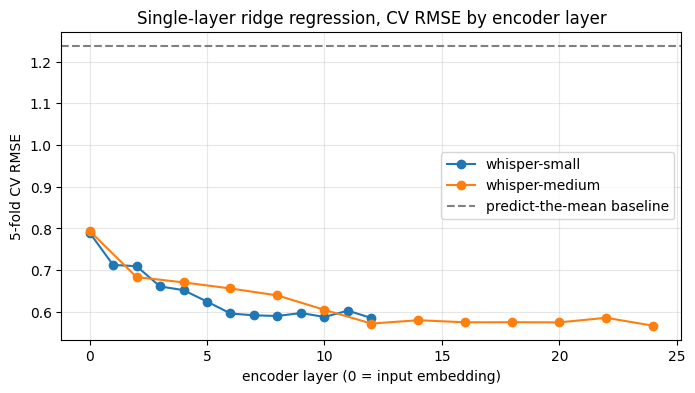

small best layers: [(12, 0.5852), (10, 0.5878), (8, 0.5902)]
medium best layers: [(24, 0.5668), (12, 0.572), (20, 0.5748)]


In [4]:
kf = KFold(5, shuffle=True, random_state=SEED)
rmse = lambda a, b: float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))
make_model = lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(1, 6, 30)))

def cv_oof(X):
    """Out-of-fold predictions with 5-fold CV (scaler and ridge are fit inside each fold)."""
    oof = np.zeros(len(y))
    for tr, va in kf.split(X):
        oof[va] = make_model().fit(X[tr], y[tr]).predict(X[va])
    return oof

layer_scores = {"small": {}, "medium": {}}
for L in range(S_tr.shape[1]):
    layer_scores["small"][L] = rmse(np.clip(cv_oof(S_tr[:, L]), 0, 5), y)
for L in range(0, M_tr.shape[1], 2):
    layer_scores["medium"][L] = rmse(np.clip(cv_oof(M_tr[:, L]), 0, 5), y)

plt.figure(figsize=(8, 4))
for name, d in layer_scores.items():
    plt.plot(list(d), list(d.values()), marker="o", label=f"whisper-{name}")
plt.axhline(y.std(), color="grey", ls="--", label="predict-the-mean baseline")
plt.xlabel("encoder layer (0 = input embedding)"); plt.ylabel("5-fold CV RMSE")
plt.title("Single-layer ridge regression, CV RMSE by encoder layer"); plt.legend(); plt.grid(alpha=.3)
plt.show()
for name, d in layer_scores.items():
    best = sorted(d, key=d.get)[:3]
    print(name, "best layers:", [(l, round(d[l], 4)) for l in best])

## 4. Combine the best layers per model, then blend the two models

In [5]:
def best_combo(tr_arr, scores, ks=(1, 2, 3, 4, 6)):
    order = sorted(scores, key=scores.get)
    res = {}
    for k in ks:
        if k > len(order):
            continue
        ids = order[:k]
        X = np.concatenate([tr_arr[:, i] for i in ids], axis=1)
        oof = cv_oof(X)
        res[k] = (rmse(np.clip(oof, 0, 5), y), ids, oof)
        print(f"  top-{k} layers {ids} | CV RMSE {res[k][0]:.4f}")
    k = min(res, key=lambda k: res[k][0])
    return res[k]

print("whisper-small:");  s_score, s_ids, oof_s = best_combo(S_tr, layer_scores["small"])
print("whisper-medium:"); m_score, m_ids, oof_m = best_combo(M_tr, layer_scores["medium"])

print("\nblend weights (w = weight on the small model):")
blend_cv = {}
for w in [0, .2, .35, .5, .65, .8, 1]:
    blend_cv[w] = rmse(np.clip((1 - w) * oof_m + w * oof_s, 0, 5), y)
    print(f"  w_small={w:<4} CV RMSE {blend_cv[w]:.4f}")
W = min(blend_cv, key=blend_cv.get)
oof_final = np.clip((1 - W) * oof_m + W * oof_s, 0, 5)
print("chosen: small layers", s_ids, "| medium layers", m_ids, "| w_small =", W)

whisper-small:
  top-1 layers [12] | CV RMSE 0.5852
  top-2 layers [12, 10] | CV RMSE 0.5794
  top-3 layers [12, 10, 8] | CV RMSE 0.5729
  top-4 layers [12, 10, 8, 7] | CV RMSE 0.5666
  top-6 layers [12, 10, 8, 7, 6, 9] | CV RMSE 0.5624
whisper-medium:
  top-1 layers [24] | CV RMSE 0.5668
  top-2 layers [24, 12] | CV RMSE 0.5481
  top-3 layers [24, 12, 20] | CV RMSE 0.5472
  top-4 layers [24, 12, 20, 16] | CV RMSE 0.5458
  top-6 layers [24, 12, 20, 16, 18, 14] | CV RMSE 0.5468

blend weights (w = weight on the small model):
  w_small=0    CV RMSE 0.5458
  w_small=0.2  CV RMSE 0.5424
  w_small=0.35 CV RMSE 0.5421
  w_small=0.5  CV RMSE 0.5436
  w_small=0.65 CV RMSE 0.5471
  w_small=0.8  CV RMSE 0.5525
  w_small=1    CV RMSE 0.5624
chosen: small layers [12, 10, 8, 7, 6, 9] | medium layers [24, 12, 20, 16] | w_small = 0.35


## 5. Final fit, training RMSE and test predictions

In [6]:
cat = lambda arr, ids: np.concatenate([arr[:, i] for i in ids], axis=1)
Xs_tr, Xs_te = cat(S_tr, s_ids), cat(S_te, s_ids)
Xm_tr, Xm_te = cat(M_tr, m_ids), cat(M_te, m_ids)

m_small = make_model().fit(Xs_tr, y)
m_med = make_model().fit(Xm_tr, y)
blend = lambda a_m, a_s: np.clip((1 - W) * a_m + W * a_s, 0, 5)

train_pred = blend(m_med.predict(Xm_tr), m_small.predict(Xs_tr))
test_pred = blend(m_med.predict(Xm_te), m_small.predict(Xs_te))

TRAIN_RMSE = rmse(train_pred, y)
CV_RMSE = rmse(oof_final, y)
print("=" * 50)
print(f"TRAINING RMSE : {TRAIN_RMSE:.4f}")
print(f"5-fold CV RMSE: {CV_RMSE:.4f}   (baseline predict-the-mean: {y.std():.4f})")
print("=" * 50)

sub = pd.DataFrame({"filename": test.filename, "label": test_pred})
assert len(sub) == 216 and sub.filename.is_unique and sub.label.between(0, 5).all()
sub.to_csv(f"{WORK}/submission.csv", index=False)
print(sub.head())

TRAINING RMSE : 0.3130
5-fold CV RMSE: 0.5421   (baseline predict-the-mean: 1.2382)
        filename     label
0  audio_128.wav  3.000999
1  audio_156.wav  4.262765
2   audio_19.wav  4.535524
3  audio_108.wav  2.121643
4  audio_206.wav  2.274158


## 6. Interpretability: where does the model do well or badly?

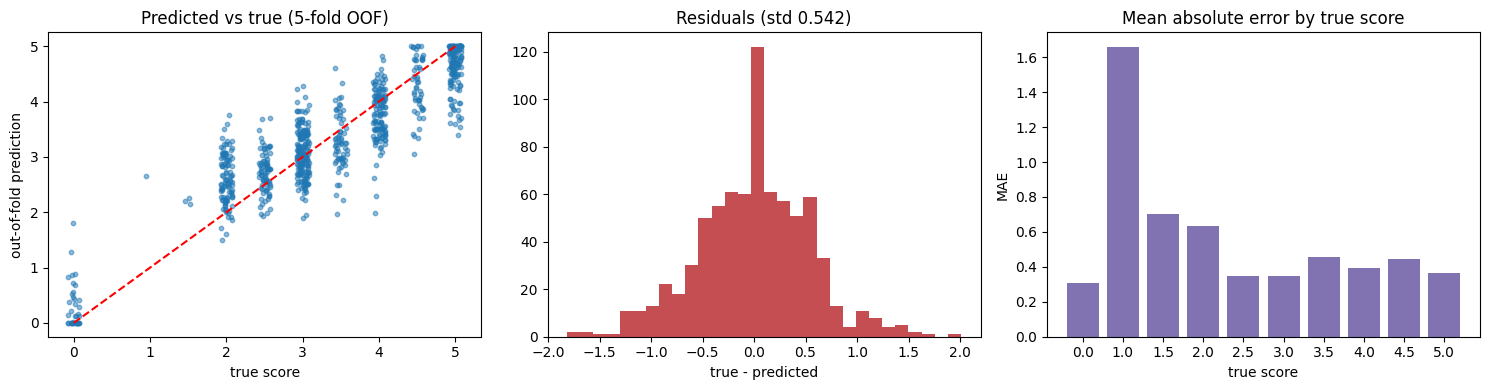

Pearson r (OOF vs true): 0.8997
Test prediction distribution: {'count': 216.0, 'mean': 3.293, 'std': 0.865, 'min': 1.584, '25%': 2.63, '50%': 3.183, '75%': 3.837, 'max': 5.0}


In [7]:
res = y - oof_final
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].scatter(y + np.random.RandomState(0).uniform(-.08, .08, len(y)), oof_final, s=10, alpha=.5)
ax[0].plot([0, 5], [0, 5], "r--"); ax[0].set_xlabel("true score"); ax[0].set_ylabel("out-of-fold prediction")
ax[0].set_title("Predicted vs true (5-fold OOF)")
ax[1].hist(res, bins=30, color="#C44E52"); ax[1].set_title(f"Residuals (std {res.std():.3f})"); ax[1].set_xlabel("true - predicted")
g = pd.DataFrame({"y": y, "abs_err": np.abs(res)}).groupby("y").abs_err.agg(["mean", "count"])
ax[2].bar(g.index.astype(str), g["mean"], color="#8172B2"); ax[2].set_title("Mean absolute error by true score")
ax[2].set_xlabel("true score"); ax[2].set_ylabel("MAE")
plt.tight_layout(); plt.show()
print("Pearson r (OOF vs true):", round(float(np.corrcoef(y, oof_final)[0, 1]), 4))
print("Test prediction distribution:", pd.Series(test_pred).describe().round(3).to_dict())

## 7. Conclusions and limitations

* A frozen Whisper encoder carries much more grammar-relevant information than handcrafted transcript features. Middle and upper encoder layers work best, and the layer-wise curve is flat from roughly layer 6 upwards.
* Ridge regression on mean-pooled embeddings is simple, fast, and robust at this dataset size; the CV RMSE is well below the predict-the-mean baseline.
* Predictions regress toward the middle of the scale (the extremes 0-1 and 5 are rare in training), which is visible in the predicted-vs-true plot and the error-by-score bars.
* Possible next steps: a second, different encoder (e.g. wav2vec2/HuBERT) in the blend, time-pooling with standard deviation as well as the mean, and ordinal or classification-style targets.

## Results summary

| Item | Value |
|---|---|
| **Training RMSE** (final blend, fit on all 769 clips) | **0.3130** |
| 5-fold CV RMSE (out-of-fold) | 0.5421 |
| Baseline RMSE (always predict the mean) | 1.2382 |
| Pearson r, OOF prediction vs true score | 0.8997 |
| Best public leaderboard RMSE (earlier submission, Whisper small + medium blend) | 0.4310 |

Chosen configuration: Whisper-small layers [12, 10, 8, 7, 6, 9], Whisper-medium layers [24, 12, 20, 16], blend weight 0.35 on the small model.

The training RMSE is lower than the CV RMSE, as expected for a model fit on the data it is scored on. The CV RMSE is the honest estimate of generalisation error.
